In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## data load in

In [4]:
path = "Data/gas_coordinates.csv"
gas = pd.read_csv(path)
gas.head()

,metro,date,regular,mid,premium,diesel,reg_delt,met,lat,lng
0,Bradenton-Sarasota-Venice,2022-01-21,3.236000,3.625,3.915000,3.563000,NaN,North Port-Bradenton-Sarasota,27.3479,-82.3223
1,Bradenton-Sarasota-Venice,2022-01-22,3.254667,3.639,3.929667,3.587667,0.576844,North Port-Bradenton-Sarasota,27.3479,-82.3223
2,Bradenton-Sarasota-Venice,2022-01-23,3.273333,3.653,3.944333,3.612333,0.573535,North Port-Bradenton-Sarasota,27.3479,-82.3223
3,Bradenton-Sarasota-Venice,2022-01-24,3.292000,3.667,3.959000,3.637000,0.570265,North Port-Bradenton-Sarasota,27.3479,-82.3223
4,Bradenton-Sarasota-Venice,2022-01-25,3.310667,3.681,3.973667,3.661667,0.567031,North Port-Bradenton-Sarasota,27.3479,-82.3223


In [5]:
path = "Data/ignore/hurr_data.csv"
hurricanes = pd.read_csv(path)
hurricanes.head()

,name,nature,date,lat,lon,wmo_wind,dist2land,landfall,usa_sshs,storm_speed,usa_roci
0,ANA,ET,2021-05-20,30.3,-55.5,30.0,1675,1669.0,-4,13.0,150.0
1,ANA,ET,2021-05-20,30.9,-55.1,NaN,1664,1628.0,-4,15.0,150.0
2,ANA,ET,2021-05-20,31.5,-54.5,35.0,1628,1580.0,-4,19.0,150.0
3,ANA,ET,2021-05-20,32.3,-53.6,NaN,1574,1513.0,-4,20.0,150.0
4,ANA,ET,2021-05-20,33.0,-53.0,40.0,1513,1446.0,-4,15.0,150.0


In [6]:
metros = gas[["metro", "lat", "lng"]].drop_duplicates()
metros.head()

,metro,lat,lng
0,Bradenton-Sarasota-Venice,27.3479,-82.3223
1440,Crestview-Fort Walton Beach,30.6657,-86.3657
2880,Daytona Beach,29.1740,-81.2197
4320,Fort Lauderdale,26.1573,-80.5059
5760,Fort Myers-Cape Coral,26.5780,-81.8332


Text(0.5, 1.0, 'Hurricane paths over Florida')

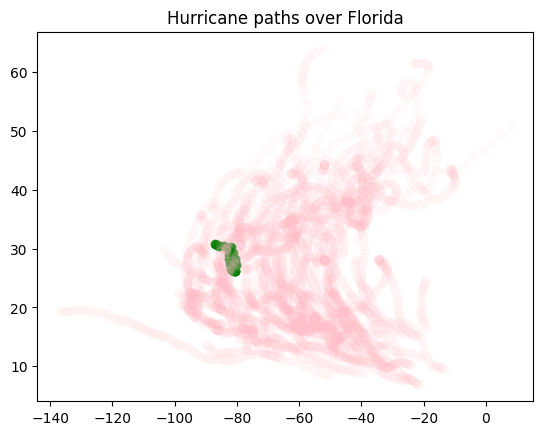

In [7]:
plt.scatter(metros["lng"], metros["lat"], color = "green")
plt.scatter(hurricanes["lon"], hurricanes["lat"], alpha=0.05, color = "pink")
plt.title("Hurricane paths over Florida")

## combining 

In [8]:
miami_lat = 25.7617
miami_lng = -80.1918

In [11]:
gas['date'].dtype == hurricanes['date'].dtype

True

In [16]:
gas['met'].unique()

<StringArray>
[          'North Port-Bradenton-Sarasota',
      'Crestview-Fort Walton Beach-Destin',
      'Deltona-Daytona Beach-Ormond Beach',
   'Miami-Fort Lauderdale-West Palm Beach',
                   'Cape Coral-Fort Myers',
                             'Gainesville',
                       'Homosassa Springs',
                            'Jacksonville',
                   'Lakeland-Winter Haven',
           'Palm Bay-Melbourne-Titusville',
                     'Naples-Marco Island',
                                   'Ocala',
               'Orlando-Kissimmee-Sanford',
           'Panama City-Panama City Beach',
              'Pensacola-Ferry Pass-Brent',
                          'Port St. Lucie',
                             'Punta Gorda',
 'Sebastian-Vero Beach-West Vero Corridor',
                                 'Sebring',
                             'Tallahassee',
         'Tampa-St. Petersburg-Clearwater',
                   'Wildwood-The Villages']
Length: 22, dtype:

In [17]:
miami = gas[gas['met'] == 'Miami-Fort Lauderdale-West Palm Beach']

In [19]:
df = miami.merge(hurricanes, on = 'date', how = 'left')

merge.head()

,metro,date,regular,mid,premium,diesel,reg_delt,met,lat_x,lng,name,nature,lat_y,lon,wmo_wind,dist2land,landfall,usa_sshs,storm_speed,usa_roci
0,Fort Lauderdale,2022-01-21,3.268,3.665,3.951,3.597000,NaN,Miami-Fort Lauderdale-West Palm Beach,26.1573,-80.5059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fort Lauderdale,2022-01-22,3.284,3.675,3.964,3.615833,0.489596,Miami-Fort Lauderdale-West Palm Beach,26.1573,-80.5059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fort Lauderdale,2022-01-23,3.300,3.685,3.977,3.634667,0.487211,Miami-Fort Lauderdale-West Palm Beach,26.1573,-80.5059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fort Lauderdale,2022-01-24,3.316,3.695,3.990,3.653500,0.484848,Miami-Fort Lauderdale-West Palm Beach,26.1573,-80.5059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fort Lauderdale,2022-01-25,3.332,3.705,4.003,3.672333,0.482509,Miami-Fort Lauderdale-West Palm Beach,26.1573,-80.5059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


distance with euclidean measure

In [20]:
df["distance"] = np.sqrt(
    (df["lat_x"] - df['lat_y'])**2 + 
    (df["lng"] - df['lon'])**2
)

In [21]:
df.head()

,metro,date,regular,mid,premium,diesel,reg_delt,met,lat_x,lng,...,nature,lat_y,lon,wmo_wind,dist2land,landfall,usa_sshs,storm_speed,usa_roci,distance
0,Fort Lauderdale,2022-01-21,3.268,3.665,3.951,3.597000,NaN,Miami-Fort Lauderdale-West Palm Beach,26.1573,-80.5059,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fort Lauderdale,2022-01-22,3.284,3.675,3.964,3.615833,0.489596,Miami-Fort Lauderdale-West Palm Beach,26.1573,-80.5059,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fort Lauderdale,2022-01-23,3.300,3.685,3.977,3.634667,0.487211,Miami-Fort Lauderdale-West Palm Beach,26.1573,-80.5059,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fort Lauderdale,2022-01-24,3.316,3.695,3.990,3.653500,0.484848,Miami-Fort Lauderdale-West Palm Beach,26.1573,-80.5059,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fort Lauderdale,2022-01-25,3.332,3.705,4.003,3.672333,0.482509,Miami-Fort Lauderdale-West Palm Beach,26.1573,-80.5059,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
import statsmodels.formula.api as smf 

reg = smf.ols("reg_delt ~ distance", data = df).fit()
print(reg.summary())

                            OLS Regression Results                            
Dep. Variable:               reg_delt   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     217.6
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           8.06e-49
Time:                        11:01:34   Log-Likelihood:                -10612.
No. Observations:               12192   AIC:                         2.123e+04
Df Residuals:                   12190   BIC:                         2.124e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0946      0.010      9.210      0.0

## hurricane exposure flag 

based on distance to storm